In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

In [4]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
print(len(cat))

345431


In [5]:
# cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
299639 299609 30
299609 299609 0
299609


In [6]:
# mask = cat['TARGET_DEC']<15
# cat = cat[mask]
# print(len(cat))

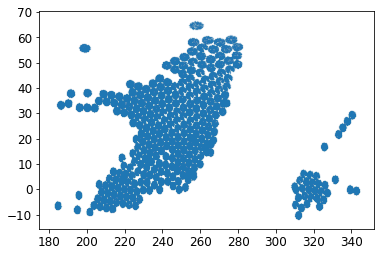

In [7]:
plt.plot(cat['TARGET_RA'], cat['TARGET_DEC'], '.', ms=0.1)
plt.show()

In [8]:
mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
print(np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat))

0.8700806718089243
260684


In [9]:
# mask = ~np.in1d(cat['PETAL_LOC'], [1, 4, 5, 8])
# cat = cat[mask]
# print(len(cat))
# print(list(np.unique(cat['PETAL_LOC'])))

In [10]:
# mask = cat['COADD_NUMEXP']==1
# cat = cat[mask]
# print(len(cat))

-------

In [11]:
# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.5
cat['q'] &= cat['DELTACHI2']>15

print(np.sum(~cat['q'])/len(cat))

0.012728053888999709


In [12]:
cat['speed'] = cat['EFFTIME_LRG']*10**(2*2.165*cat['EBV']/2.5)/cat['COADD_EXPTIME']
# cat['speed_noebv'] = cat['EFFTIME_LRG']/cat['COADD_EXPTIME']

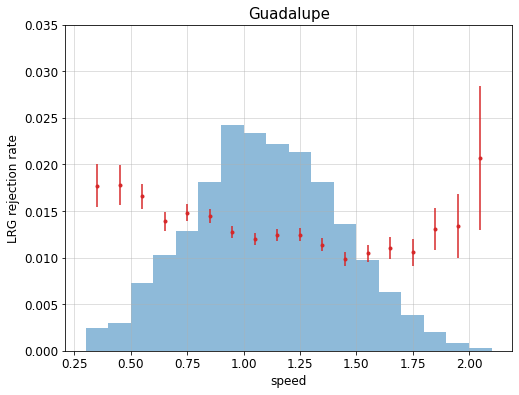

In [13]:
mask = np.full(len(cat), True)
bin_edges = np.arange(0.3, 2.2, 0.1)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['speed'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('speed')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
plt.ylim(0, 0.035)
plt.hist(cat['speed'], bins=bin_edges, weights=np.full(len(cat), 0.2*1/len(cat)), alpha=0.5)
plt.title('Guadalupe', fontsize=15)
plt.show()

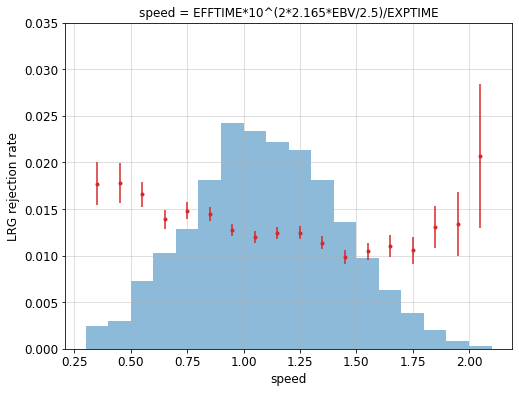

In [14]:
mask = np.full(len(cat), True)
bin_edges = np.arange(0.3, 2.2, 0.1)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['speed'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('speed')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
plt.ylim(0, 0.035)
plt.hist(cat['speed'], bins=bin_edges, weights=np.full(len(cat), 0.2*1/len(cat)), alpha=0.5)
plt.title('speed = EFFTIME*10^(2*2.165*EBV/2.5)/EXPTIME')
plt.show()

In [15]:
t = Table()
t['speed_min'] = bin_edges[:-1]
t['speed_max'] = bin_edges[1:]
t['speed_min'].format = '%.2f'
t['speed_max'].format = '%.2f'
t['LRG_success_rate'] = 1-bin_reject_rate
t['LRG_success_rate'].format = '%.4f'
t['LRG_success_rate_error'] = bin_reject_rate_err
t['LRG_success_rate_error'].format = '%.4f'
t.write('data/lrg_success_rate_vs_speed.txt', format='ascii.commented_header', 
       formats={'speed_min':'%4.2f', 'speed_max':'%4.2f', 'LRG_success_rate':'%.4f', 'LRG_success_rate_error':'%.4f'},
       overwrite=True)
t

speed_min,speed_max,LRG_success_rate,LRG_success_rate_error
float64,float64,float64,float64
0.30,0.40,0.9823,0.0023
0.40,0.50,0.9822,0.0021
0.50,0.60,0.9834,0.0013
0.60,0.70,0.9861,0.0010
0.70,0.80,0.9852,0.0009
0.80,0.90,0.9856,0.0008
0.90,1.00,0.9872,0.0006
1.00,1.10,0.9880,0.0006
1.10,1.20,0.9876,0.0007


-----

In [16]:
# exp = Table.read('/global/cfs/cdirs/desi/spectro/redux/guadalupe/exposures-guadalupe.csv')
exp = Table.read('/Users/rongpu/Documents/Data/desi_data/fugu/misc/exposures-guadalupe.csv')
print(len(exp))

mask = exp['EXPTIME']>250
exp = exp[mask]
print(len(exp))

mask = np.in1d(exp['TILEID'], cat['TILEID'])
exp = exp[mask]
print(len(exp))

print(len(exp), len(np.unique(exp['TILEID'])), len(np.unique(cat['TILEID'])))

786
781
376
376 305 305


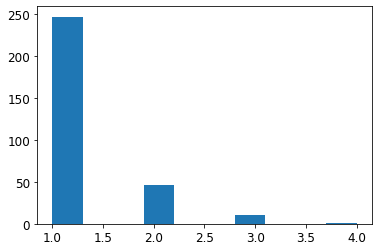

46
303 275


In [17]:
# Only include tiles from single exposures or back-to-back double exposures 

t = Table()
t['TILEID'], t['count'] = np.unique(exp['TILEID'], return_counts=True)
t.sort('count')
# t.pprint_all()
# t
plt.hist(t['count'], 10)
plt.show()

# Find back-to-back exposures
expid_to_include = []
mask = t['count']==2
print(np.sum(mask))
for tileid in t['TILEID'][mask]:
    idx = np.where(exp['TILEID']==tileid)[0]
    expid_diff = np.abs(exp['EXPID'][idx[0]]-exp['EXPID'][idx[1]])
    if expid_diff==1:
        expid_to_include+=list(exp['EXPID'][idx])

mask = t['count']==1
mask_exp = np.in1d(exp['TILEID'], t['TILEID'][mask])
mask_exp |= np.in1d(exp['EXPID'], expid_to_include)
exp = exp[mask_exp]
print(len(exp), len(np.unique(exp['TILEID'])))

In [18]:
# t = Table()
# t['TILEID'], t['count'] = np.unique(exp['TILEID'], return_counts=True)
# t.sort('count')
# mask = t['count']>1
# t[mask]

# mask = exp['TILEID']==t['TILEID'][mask][0]
# exp[mask]

303 275
275 275


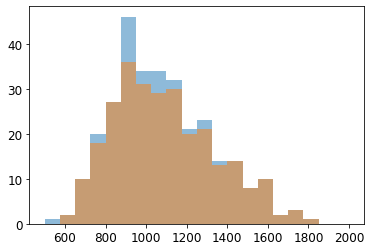

275 275


In [19]:
print(len(exp), len(np.unique(exp['TILEID'])))

# For coadds of multiple exposures, only keep the longest exposure
exp.sort('EXPTIME', reverse=True)
_, idx_keep = np.unique(exp['TILEID'], return_index=True)

exp1 = exp[idx_keep]
print(len(exp1), len(np.unique(exp1['TILEID'])))

plt.hist(exp['EXPTIME'], 20, range=(500, 2000), alpha=0.5)
plt.hist(exp1['EXPTIME'], 20, range=(500, 2000), alpha=0.5)
plt.show()

exp = exp1
print(len(exp), len(np.unique(exp['TILEID'])))

In [20]:
exp = exp[['TILEID', 'AIRMASS', 'SEEING_ETC', 'TRANSPARENCY_GFA', 'SEEING_GFA', 'AIRMASS_GFA', 'SKY_MAG_AB_GFA', 'SKY_MAG_G_SPEC', 'SKY_MAG_R_SPEC', 'SKY_MAG_Z_SPEC']]

print(len(cat))
cat = join(cat, exp, keys='TILEID')
print(len(cat))

260684
240918


--------

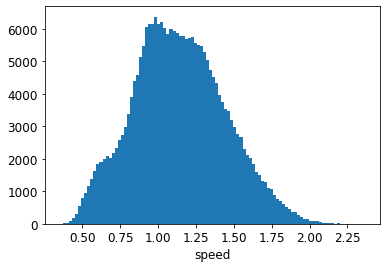

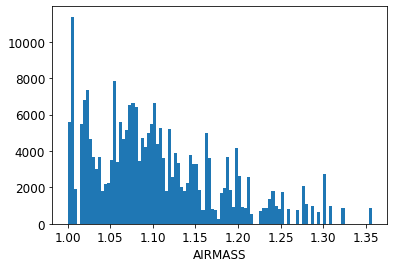

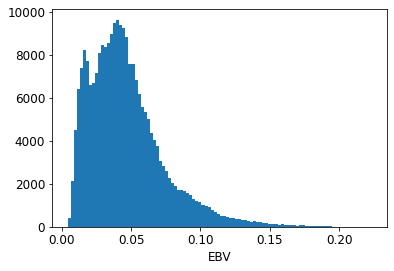

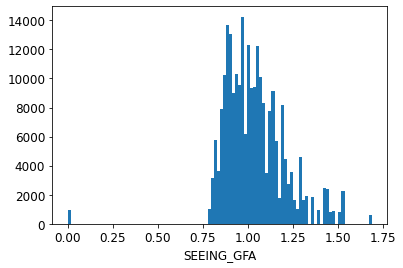

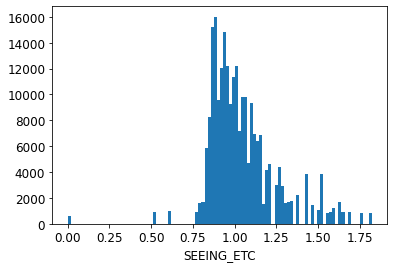

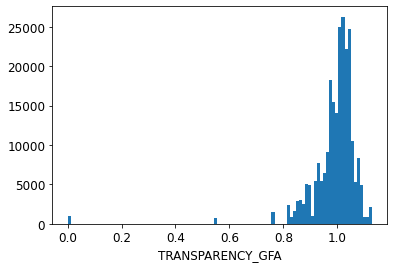

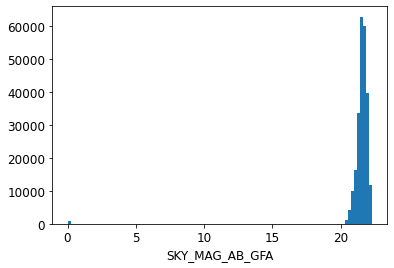

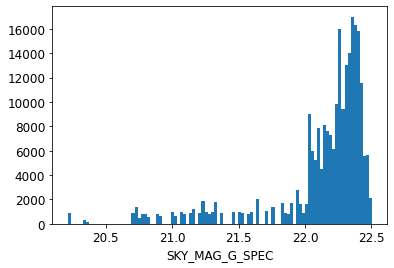

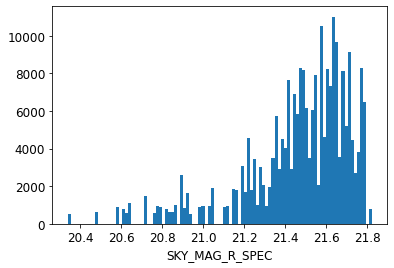

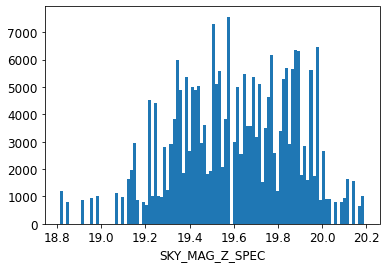

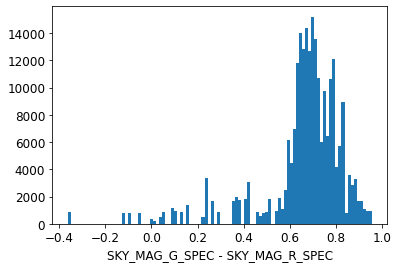

In [21]:
plt.hist(cat['speed'], 100)
plt.xlabel('speed')
plt.show()

plt.hist(cat['AIRMASS'], 100)
plt.xlabel('AIRMASS')
plt.show()

plt.hist(cat['EBV'], 100)
plt.xlabel('EBV')
plt.show()

plt.hist(cat['SEEING_GFA'], 100)
plt.xlabel('SEEING_GFA')
plt.show()

plt.hist(cat['SEEING_ETC'], 100)
plt.xlabel('SEEING_ETC')
plt.show()

plt.hist(cat['TRANSPARENCY_GFA'], 100)
plt.xlabel('TRANSPARENCY_GFA')
plt.show()

plt.hist(cat['SKY_MAG_AB_GFA'], 100)
plt.xlabel('SKY_MAG_AB_GFA')
plt.show()

plt.hist(cat['SKY_MAG_G_SPEC'], 100)
plt.xlabel('SKY_MAG_G_SPEC')
plt.show()

plt.hist(cat['SKY_MAG_R_SPEC'], 100)
plt.xlabel('SKY_MAG_R_SPEC')
plt.show()

plt.hist(cat['SKY_MAG_Z_SPEC'], 100)
plt.xlabel('SKY_MAG_Z_SPEC')
plt.show()

plt.hist(cat['SKY_MAG_G_SPEC']-cat['SKY_MAG_R_SPEC'], 100)
plt.xlabel('SKY_MAG_G_SPEC - SKY_MAG_R_SPEC')
plt.show()

[1.         1.02368421 1.04736842 1.07105263 1.09473684 1.11842105
 1.14210526 1.16578947 1.18947368 1.21315789 1.23684211 1.26052632
 1.28421053 1.30789474 1.33157895 1.35526316 1.37894737 1.40263158
 1.42631579 1.45      ]


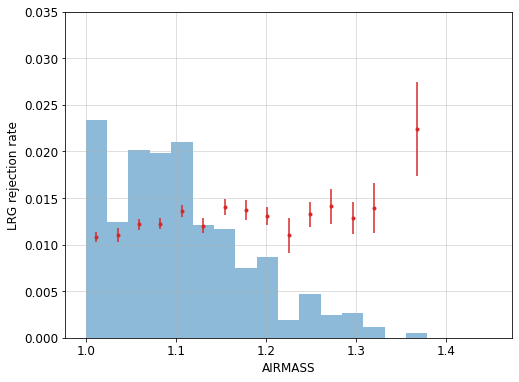

In [22]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(1., 1.45, 20)
print(bin_edges)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['AIRMASS'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('AIRMASS')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['AIRMASS'], bins=bin_edges, weights=np.full(len(cat), 0.15*1/len(cat)), alpha=0.5)
plt.show()

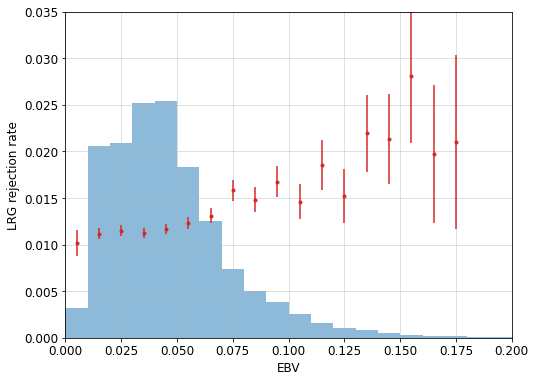

In [23]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0., 0.2, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EBV'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('EBV')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.axis([0.0, 0.2, 0., 0.035])
plt.hist(cat['EBV'], bins=bin_edges, weights=np.full(len(cat), 0.15*1/len(cat)), alpha=0.5)
plt.show()

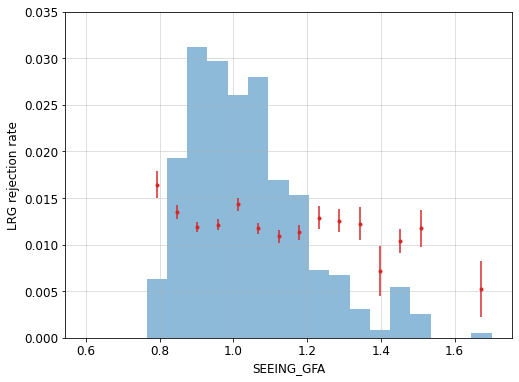

In [24]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0.6, 1.7, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SEEING_GFA'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SEEING_GFA')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SEEING_GFA'], bins=bin_edges, weights=np.full(len(cat), 0.2*1/len(cat)), alpha=0.5)
plt.show()

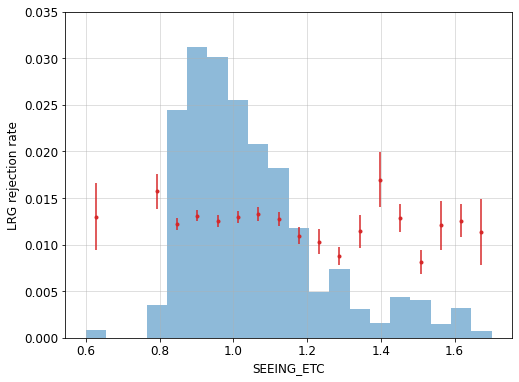

In [25]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0.6, 1.7, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SEEING_ETC'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SEEING_ETC')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SEEING_ETC'], bins=bin_edges, weights=np.full(len(cat), 0.2*1/len(cat)), alpha=0.5)
plt.show()

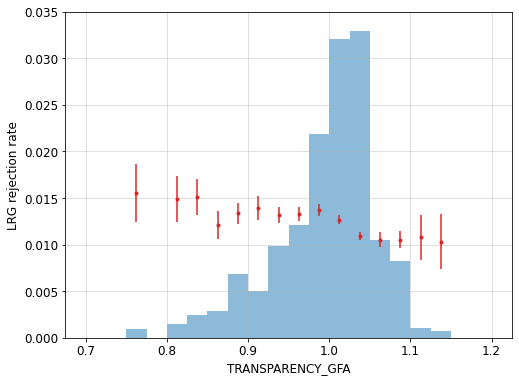

In [26]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0.7, 1.2, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['TRANSPARENCY_GFA'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('TRANSPARENCY_GFA')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['TRANSPARENCY_GFA'], bins=bin_edges, weights=np.full(len(cat), 0.15*1/len(cat)), alpha=0.5)
plt.show()

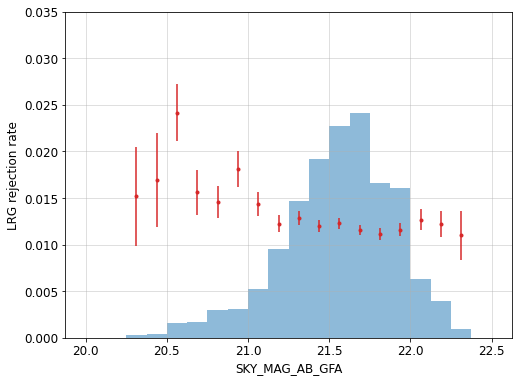

In [27]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(20., 22.5, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SKY_MAG_AB_GFA'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SKY_MAG_AB_GFA')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SKY_MAG_AB_GFA'], bins=bin_edges, weights=np.full(len(cat), 0.15*1/len(cat)), alpha=0.5)
plt.show()

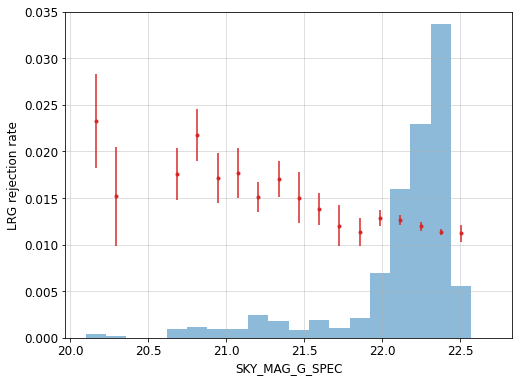

In [28]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(20.1, 22.7, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SKY_MAG_G_SPEC'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SKY_MAG_G_SPEC')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SKY_MAG_G_SPEC'], bins=bin_edges, weights=np.full(len(cat), 0.1*1/len(cat)), alpha=0.5)
plt.show()

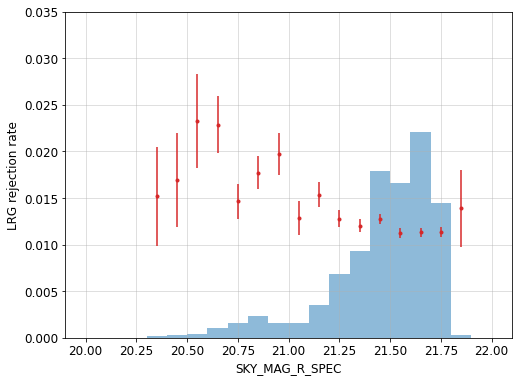

In [29]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(20., 22., 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SKY_MAG_R_SPEC'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SKY_MAG_R_SPEC')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SKY_MAG_R_SPEC'], bins=bin_edges, weights=np.full(len(cat), 0.1*1/len(cat)), alpha=0.5)
plt.show()

In [30]:
np.median(cat['SKY_MAG_Z_SPEC'])

19.613

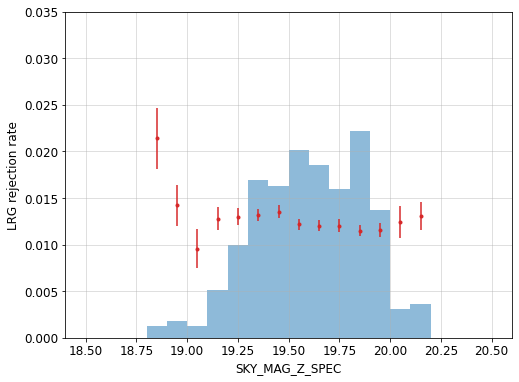

In [31]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(18.5, 20.5, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['SKY_MAG_Z_SPEC'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SKY_MAG_Z_SPEC')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist(cat['SKY_MAG_Z_SPEC'], bins=bin_edges, weights=np.full(len(cat), 0.15*1/len(cat)), alpha=0.5)
plt.show()

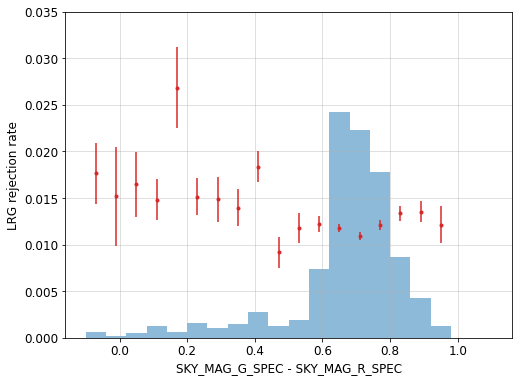

In [32]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(-0.1, 1.1, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac((cat['SKY_MAG_G_SPEC']-cat['SKY_MAG_R_SPEC'])[mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('SKY_MAG_G_SPEC - SKY_MAG_R_SPEC')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.ylim(0, 0.035)
plt.hist((cat['SKY_MAG_G_SPEC']-cat['SKY_MAG_R_SPEC']), bins=bin_edges, weights=np.full(len(cat), 0.1*1/len(cat)), alpha=0.5)
plt.show()

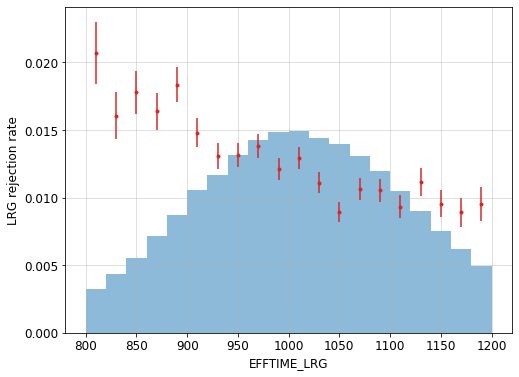

In [33]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(800, 1200, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~cat['q'])[mask], bin_edges, minsize=200)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate, color='C3',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label=None)
plt.xlabel('EFFTIME_LRG')
plt.ylabel('LRG rejection rate')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
# plt.axis([0.0, 0.2, 0., 0.05])
plt.hist(cat['EFFTIME_LRG'], bins=bin_edges, weights=np.full(len(cat), 0.2*1/len(cat)), alpha=0.5)
plt.show()

-------
## Check EBV trend after accounting for EFFTIME and zfiber

In [34]:
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['qf'] = np.array(cat['q'], dtype=float)

In [35]:
def failure_rate(flux, efftime, a, b, c):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(-(sn+a)/b)+c/flux, 0, 1)

# From Main LRGs + SV3 LRGs + Main LRGs from SV1; EBV<0.1
params = [-3.25288364e+01,  1.11713253e+01,  2.92794005e-02]

In [36]:
cat['success_prob'] = 1-failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *params)
print(np.sum(~cat['q']), np.sum(1-cat['success_prob']))
print(np.sum(~cat['q'])/np.sum(1-cat['success_prob']))

2994 2856.57
1.0481101210024075


In [37]:
def binned_frac_complicated(x, y, y1, bin_edges, minsize=200):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p, p1 = np.sum(mask), np.mean(y[mask]), np.mean(y1[mask])
            bin_frac[index] = p
            bin_frac_err[index] = np.sqrt(n * p1 * (1-p1))/n
    
    return bin_center, bin_frac, bin_frac_err

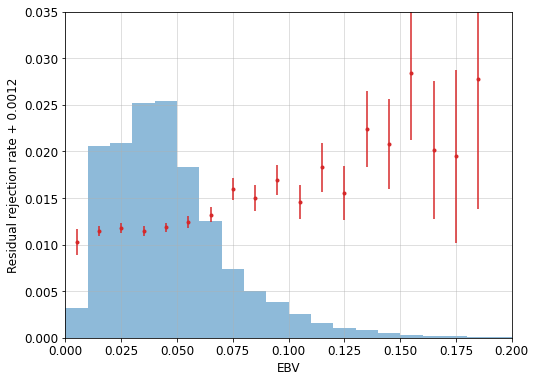

In [38]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0., 0.2, 21)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac_complicated(cat['EBV'][mask], (1-cat['qf']/cat['success_prob'])[mask], (~cat['q'][mask]), bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate+0.012, color='C3',
             yerr=bin_reject_rate_err,
             fmt='.', label=None)
plt.xlabel('EBV')
plt.ylabel('Residual rejection rate + 0.0012')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
# plt.axis([0.0, 0.2, -0.01, 0.034])
plt.axis([0.0, 0.2, 0., 0.035])
plt.hist(cat['EBV'], bins=bin_edges, weights=np.full(len(cat), 0.15/len(cat)), alpha=0.5)
plt.show()